In [1]:
#| default_exp data.database.processing

In [2]:
#| hide
from nbdev.showdoc import *
from oauthlib.uri_validate import query
from pyasn1_modules.rfc3279 import id_fieldType

In [3]:
#| hide
import nbdev; nbdev.nbdev_export()

In [4]:
#| hide
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [5]:
from statistics import median
# from fiona.env import local

In [6]:
#| export
import os
import pandas as pd 
import pandas_gbq

In [7]:
#| export
from sqlalchemy import MetaData, create_engine, asc, desc, and_, or_, not_, case, extract, cast, Numeric, text, distinct, Column, update, bindparam, Engine
from sqlalchemy.types import DateTime, Date, Time, String
from sqlalchemy.schema import *
from sqlalchemy.sql import func as F, Selectable, select, union, insert
from sqlalchemy.dialects import registry
from sqlalchemy.engine.row import Row
from sqlalchemy.orm import Session
from sqlalchemy.orm import sessionmaker
import requests
from tqdm.notebook import tqdm

In [8]:

from concurrent.futures import ThreadPoolExecutor, as_completed
import httpx
from http import HTTPStatus
from concurrent import futures
from enum import Enum
import numpy as np
import country_converter as coco
import pycountry
import pgeocode
from geopy.geocoders import Nominatim
import holidays
import warnings
from datetime import datetime


# local table from local sqlite database

## Sql Lookup by join a lookup table

In [9]:
sql_eng = create_engine('sqlite:///../data/price_training_raw.db', echo=False)
sql_conn = sql_eng.connect()
sql_metadata = MetaData()
Sql_Session = sessionmaker(bind=sql_eng)
sql_session = Sql_Session()


In [10]:
sql_eng3 = create_engine('sqlite:///../data/price_ts.db', echo=False)
sql_conn3 = sql_eng3.connect()
sql_metadata3 = MetaData()
Sql_Session3 = sessionmaker(bind=sql_eng3)
sql_session3 = Sql_Session3()


In [16]:
# price_training_newyork = Table('price_training_newyork', sql_metadata, autoload_with=sql_eng)
# total_rows = sql_session.query(price_training_newyork).count()
# print(total_rows)

# price_training_newyork.metadata.create_all(sql_eng3)
# data = sql_session.query(price_training_newyork).all()
# # for row in data:
# #     sql_session3.execute(price_training_newyork.insert().values(row._asdict()), )
# sql_session3.execute(price_training_newyork.insert(), [row._asdict() for row in data])
# sql_session3.commit()
# sql_session.close()
# sql_session3.close()

In [18]:

dispatches_t = Table('price_training_newyork', sql_metadata3, autoload_with=sql_eng3)
total_rows = sql_session3.query(dispatches_t).count()
print(total_rows)


321259


In [19]:
df_newyork = pd.read_sql(select(dispatches_t), sql_conn3)
df_newyork

,dispatch_id,ride_id,trip_count,ride_inserted_at,from_utc,from_time_str,from_timezone_str,to_time_str,to_timezone_str,passenger_count,...,start_ltt,end_place_id,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end
0,155,2164872,1,2020-05-25 06:45:14.000000,1.590431e+09,2020-05-25 14:30,Eastern Daylight Time,None,None,1.0,...,40.808108,9,John F. Kennedy International Airport,-73.778139,40.641311,1.0,Sedan,1,,
1,8144,2168707,1,2021-02-22 12:46:16.000000,1.614126e+09,2021-02-23 19:15,America/New_York,None,None,2.0,...,40.643351,3379,7 W 45th St,-73.980025,40.755955,1.0,Sedan,1,,
2,8300,2168774,1,2021-02-26 23:20:34.000000,1.614475e+09,2021-02-27 20:15,Eastern Standard Time,None,None,2.0,...,40.641311,3440,98 Frelinghuysen Ave,-74.185363,40.718531,1.0,Sedan,1,,
3,11335,2170440,1,2021-04-09 12:39:59.000000,1.619531e+09,2021-04-27 09:37,America/New_York,None,None,1.0,...,40.979118,9,John F. Kennedy International Airport,-73.778139,40.641311,1.0,Sedan,1,,
4,11477,2170519,1,2021-04-10 18:54:08.000000,1.628248e+09,2021-08-06 07:00,America/New_York,None,None,4.0,...,40.758586,11,New York LaGuardia Airport,-73.873966,40.776927,6.0,MPV-4,1,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321254,3338410,3108520,1,2024-01-05 07:42:13.000000,1.729281e+09,2024-10-18 15:45,America/New_York,None,None,2.0,...,40.764156,920953,Terminal 8,-73.790623,40.647453,1.0,Sedan,1,,
321255,3411723,3098061,2,2024-01-02 13:57:49.000000,1.729966e+09,2024-10-26 14:05,America/New_York,2024-10-30 17:10,America/New_York,3.0,...,40.644624,905636,Arlo Midtown,-73.993787,40.755740,1.0,Sedan,1,,
321256,3439635,3096570,2,2024-01-01 20:39:14.000000,1.727817e+09,2024-10-01 17:15,America/New_York,2024-10-07 15:20,America/New_York,2.0,...,40.649529,902983,"Distrikt Hotel New York City, Tapestry Collection",-73.992844,40.756686,1.0,Sedan,1,,
321257,3462020,3394821,2,2024-04-12 03:30:20.000000,1.729380e+09,2024-10-19 19:15,America/New_York,2024-10-26 04:05,America/New_York,3.0,...,40.644624,1472725,RIU Plaza Manhattan Times Square,-73.983607,40.758902,1.0,Sedan,1,,


# Connect to Google BigQuery

In [16]:
#| export
from google.oauth2 import service_account
import os
from google.oauth2.service_account import Credentials

#| hide
from google.cloud import bigquery
from dotenv import load_dotenv

In [17]:

load_dotenv("../.env")
os.environ


True

environ{'GSM_SKIP_SSH_AGENT_WORKAROUND': 'true',
        'LC_ALL': 'en_US.UTF-8',
        'WINDOWPATH': '2',
        'PATH': '/vlt/.pyenv/versions/miniforge3-latest/envs/prc/bin:/vlt/.pyenv/versions/miniforge3-latest/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin',
        'CONDA_PREFIX': '/vlt/.pyenv/versions/miniforge3-latest/envs/prc',
        'LIBVIRT_DEFAULT_URI': 'qemu:///system',
        'LOGNAME': 'x',
        'XDG_CONFIG_DIRS': '/etc/xdg/xdg-cinnamon:/etc/xdg',
        'XAUTHORITY': '/run/user/1000/gdm/Xauthority',
        'XDG_SESSION_ID': '3',
        'CONDA_SHLVL': '1',
        'XMODIFIERS': '@im=ibus',
        'GIO_LAUNCHED_DESKTOP_FILE_PID': '254696',
        'GIO_LAUNCHED_DESKTOP_FILE': '/home/x/Desktop/pycharm.desktop',
        'QT_ACCESSIBILITY': '1',
        'CONDA_DEFAULT_ENV': 'prc',
        'XDG_SEAT': 'seat0',
        'XDG_VTNR': '2',
        'QTWEBENGINE_DICTIONARIES_PATH': '/usr/share/hunspel

In [18]:
key = os.getenv('GC_QUOTE_API_CREDENTIALS')
credential = service_account.Credentials.from_service_account_file("../" + key)
# key_test = os.getenv('GC_TEST_API_CREDENTIALS')
# credential_test = service_account.Credentials.from_service_account_file("../" + key_test)

In [19]:
registry.register('bigquery', 'sqlalchemy_bigquery', 'BigQueryDialect')
gbq_eng = create_engine('bigquery://quote-api-365206',
                       credentials_path='../' + key)
gbq_conn = gbq_eng.connect()
gbq_metadata = MetaData()
Gbq_session = sessionmaker(bind=gbq_eng)
gbq_session = Gbq_session()
gbq_client = bigquery.Client(credentials=credential)

In [20]:

# pandas_gbq.to_gbq(df_dispatch_feature_routes_2324_fix,
#                   "price.dispatch_feature_routes_2324_sa_fix",
#                   project_id="elife-data-warehouse-test",
#                   if_exists="replace")


In [21]:
# engine_test = create_engine('bigquery://elife-data-warehouse-test',
# engine_test = create_engine('bigquery://quote-api-365206',
#                        credentials_path='../' + key_test )
# metadata_test = MetaData()
# type(engine_test)

In [22]:

def get_table(project_name: str, dataset_name: str, table_name: str, engine: Engine, meta_data: MetaData) -> Table:
    table = Table(f'{project_name}.{dataset_name}.{table_name}', meta_data, autoload_with=engine)
    return table

In [23]:
# fpz_lut_t = get_table('elife-data-warehouse-test', 'price', 'dispatch_feature_routes_2324_sa_fix', gbq_eng, gbq_metadata).alias()
# print(f"fpz_lut: {gbq_session.query(fpz_lut_t).count()}")
# fpz_query_t = get_table('elife-data-warehouse-test', 'price', 'fixed_zone_routes', gbq_eng, gbq_metadata).alias()
# print(f"fpz_query: {gbq_session.query(fpz_query_t).count()}")


In [24]:
# route_samples = select(fpz_lut_t)
# route_samples = select(dispatch_routes_t)


In [25]:
# # df_dispatch_routes = pd.read_sql(route_samples, gbq_conn)  #gbq
# df_dispatch_routes = pd.read_sql(route_samples, sql_conn2, index_col = 'dispatch_id')  #sqlite3
# # df_dispatch_routes = pd.read_csv('../data/dispatch_routes_gc.csv') #, index_col='dispatch_id')
# df_dispatch_routes

In [26]:
# query_input = df_dispatch_routes.iloc[2000,:]
# # query_input.loc[['dispatch_id','route_start','route_end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','service_area','trip_count','trip_no']]
# query_input

In [27]:
sql_eng2 = create_engine('sqlite:///../data/price_2324.db', echo=False)
sql_conn2 = sql_eng2.connect()
sql_metadata2 = MetaData()
Sql_Session2 = sessionmaker(bind=sql_eng2)
sql_session2 = Sql_Session2()

routes_t = Table('routes_vehicle_class_2324', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

19482


In [28]:
df_routes_vehicle_class = pd.read_sql(select(routes_t), sql_conn)
df_routes_vehicle_class.shape

(19482, 59)

In [29]:
# df_routes_vehicle_class.to_sql('routes_vehicle_class_2324', sql_eng2, if_exists='replace', index=False)

In [30]:
service_areas_2324_fix_t = Table('service_areas_2324_fix', sql_metadata2, autoload_with=sql_eng2)
df_service_areas_fix = pd.read_sql(select(service_areas_2324_fix_t), sql_conn2, index_col='service_area_id')
df_service_areas_fix


,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix,holidays
service_area_id,,,,,,,,,,,,,,,,,,,,,
55,49.19669,-123.18151,49.28247,-123.11861,87749,183908,2206773,1,1.693854e+09,2023-09-04 12:00,...,49.282469,1.0,Sedan,1,YVR,Vancouver,None,None,"Vancouver,Canada",11
99,29.65561,-95.27792,29.30810,-94.79726,101558,52498,2213222,1,1.702665e+09,2023-12-15 12:30,...,29.308097,3.0,MPV-5,1,HOU,"Galveston, TX",None,None,"Houston,USA",13
38,37.61487,-122.38985,37.79414,-122.40779,123241,128980,2222284,1,1.740210e+09,2025-02-21 23:45,...,37.794138,1.0,Sedan,1,SFO,san francisco,None,None,"San Francisco, USA",14
165,19.43608,-99.07191,19.28447,-99.14919,140298,68154,2230107,1,1.682032e+09,2023-04-20 17:00,...,19.284467,1.0,Sedan,1,MEX,Mexico city south,None,None,"Mexico City,Mexico",8
40,40.75203,-73.98472,40.64131,-73.77814,155022,84728,2238054,1,1.672850e+09,2023-01-04 11:30,...,40.641311,6.0,MPV-4,1,曼哈顿,JFK,None,None,"New York,USA",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,51.97723,7.61082,52.13460,7.68483,2705826,113316,3486413,1,1.722760e+09,2024-08-04 10:35,...,52.134602,1.0,Sedan,1,Münster,FMO,None,None,"Greven, Germany",9
1158,54.08330,-4.62389,54.18296,-4.47545,2774762,115116,3512920,1,1.717832e+09,2024-06-08 08:30,...,54.182957,1.0,Sedan,1,IOM,Douglas,None,None,Isle of Man,10
1419,46.62088,14.30649,46.65001,14.32486,2779550,102324,3520706,1,1.718618e+09,2024-06-17 12:00,...,46.650013,6.0,MPV-4,1,Klagenfurt,KLU,None,None,"Klagenfurt,Austria",13


In [31]:
dispatch_routes_t = Table('dispatch_feature_routes_2324_sa_fix', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session2.query(dispatch_routes_t).count()
print(total_rows)

1061218


In [32]:

df_dispatch_routes = pd.read_sql(select(dispatch_routes_t), sql_conn2, index_col='dispatch_id')  #sqlite3
df_dispatch_routes

,index,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
dispatch_id,,,,,,,,,,,,,,,,,,,,,
1845170,0,2023-12-28 13:30:00,America/Argentina/Ushuaia,2023-12-18 16:52:11.000000,2023-12-18 16:52:11.000000,-54.8433,-68.2958,-54.80739,-68.30829,3064977,...,2.0,3.0,NaN,NaN,5989.0,751.0,USH,Ushuaia,"Ushuaia,Argentina",19
1717512,1,2024-03-02 11:25:00,America/Argentina/Ushuaia,2023-11-25 01:17:33.000000,2023-11-25 01:17:33.000000,-54.8433,-68.2958,-54.80724,-68.30465,3002859,...,2.0,3.0,NaN,NaN,6302.0,747.0,USH,Ushuaia,"Ushuaia,Argentina",19
2882892,2,2024-08-01 12:00:00,America/Argentina/Ushuaia,2024-03-30 12:35:43.000000,2024-07-01 15:00:22.000000,-54.8433,-68.2958,-54.80733,-68.30539,3363605,...,3.0,3.0,NaN,NaN,6350.0,772.0,USH,Ushuaia,"Ushuaia,Argentina",19
2029084,3,2024-07-24 21:25:00,America/Argentina/Ushuaia,2024-01-22 00:00:29.000000,2024-01-22 00:00:29.000000,-54.8433,-68.2958,-54.80501,-68.30144,3159454,...,2.0,3.0,NaN,NaN,6540.0,841.0,USH,Ushuaia,"Ushuaia,Argentina",19
2484384,4,2024-05-12 10:40:00,Argentina Standard Time,2023-12-05 17:30:18.000000,2024-04-08 16:00:12.000000,-54.8433,-68.2958,-54.80932,-68.31662,3031625,...,2.0,3.0,0.0,0.0,5414.0,666.0,USH,Ushuaia,"Ushuaia,Argentina",19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520967,1061288,2023-10-19 22:55:00,Europe/Oslo,2023-10-01 21:31:32.000000,2023-10-18 08:34:14.000000,69.6833,18.9189,69.64816,18.95722,2860188,...,1.0,3.0,NaN,NaN,4968.0,552.0,IVL,Nellim,"Tromso, Norway",12
1234482,1061289,2023-11-13 18:40:00,Europe/Oslo,2023-08-15 20:58:24.000000,2023-08-15 20:58:24.000000,69.6833,18.9189,69.64894,18.95969,2759268,...,2.0,4.0,NaN,NaN,5157.0,660.0,TOS,Tromso,"Tromso, Norway",12
1757195,1061290,2024-02-22 13:30:00,Europe/Oslo,2023-12-02 15:05:37.000000,2023-12-02 15:05:37.000000,69.6833,18.9189,69.64803,18.95366,3023087,...,2.0,3.0,NaN,NaN,4792.0,490.0,TOS,Tromso,"Tromso, Norway",12


In [33]:
query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
ltt, lng = query_input['start_ltt_lp'], query_input['start_lng_lp']
ltt, lng



('MEL', 'St Kilda圣基尔达', np.float64(71.36), np.int64(140), np.float64(1.0))

(np.float64(-37.669), np.float64(144.8388))

In [34]:
# df = pd.read_sql(select(dispatch_routes_t),con=sql_conn2)
# df.head()
# df.shape

In [35]:
p0 = datetime.strptime('07:00:00', '%H:%M:%S').time()
p1 = datetime.strptime('09:00:00', '%H:%M:%S').time()
p2 = datetime.strptime('16:00:00', '%H:%M:%S').time()
p3 = datetime.strptime('19:00:00', '%H:%M:%S').time()
n0 = datetime.strptime('22:00:00', '%H:%M:%S').time()
n1 = datetime.strptime('06:00:00', '%H:%M:%S').time()
peak_time_str = [(p0, p1), (p2, p3)]
night_time_str = [(n0, n1)] # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am


In [46]:
# routes_t = Table('routes_vehicle_class_2324', sql_metadata2, autoload_with=sql_eng2)
routes_t = Table('routes_vehicle_class_2324_na', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session2.query(routes_t).count()
print(total_rows)

pd.options.mode.copy_on_write = True
max_concurrent = 48
chunk_size=100
non_cp_count = 0
routes_q = select(routes_t)


6906


In [ ]:
warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.")
pd.set_option('future.no_silent_downcasting', True)
CostQueryStatus = Enum('CostQueryStatus', 'NoCountryCode NoStateCode NoHistorySamples NonBase Success')
cost_profit = {'cost': None, 'profit': None}
local_holidays = None

def country_and_state_codes_from_geocoord(latitude, longitude):
    geolocator = Nominatim(user_agent="geocodequery")
    location = geolocator.reverse((latitude, longitude), exactly_one=True)

    if location:
        address = location.raw['address']
        country_code = address.get('country_code', None)
        state_code = address.get('state_code', None)

        return (country_code.upper(), state_code)

    return (None, None)

# country_and_state_codes_from_geocoord(ltt, lng)

def feature_extract(x):
    global local_holidays
    x.loc['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x.loc['weekday'] = x['from_datetime'].day_name()
    x.loc['dayofweek'] = x['from_datetime'].weekday()
    # x.loc['country_alpha_2'] = subdv_code[0]
    # x.loc['country_subdiv'] = subdv_code[1]
    if local_holidays:
        x.loc['holiday'] = x['from_datetime'] in local_holidays
    else:
        x.loc['holiday'] = False
    t = x['from_datetime'].time()
    x.loc['peak_time'] = p0 < t < p1 or p2 < t < p3
    x.loc['nighttime'] = n0 < t or t < n1
    return x

def cost_profit_extract(x):
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit
    # x['profit_rate'] = profit/ cost 

    return x

def cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id) -> CostQueryStatus: 
    global cost_profit,local_holidays
    route_hist_dispatches = (
        select(dispatch_routes_t)
        .where(
            and_(
                dispatch_routes_t.c.route_start == route_from_zone,
                dispatch_routes_t.c.route_end == route_to_zone,
                dispatch_routes_t.c.service_area_id == int(service_area_id),
                dispatch_routes_t.c.vehicle_class_id == int(vehicle_class_id),
            )
        )
        .select_from(dispatch_routes_t)
    )
    
    # Execute the statement and fetch the results
    # print("Executing query")
    df_query = pd.read_sql(route_hist_dispatches, sql_eng2)
    # print("Query executed")
    if df_query.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    
    df_query = df_query.astype({
        'from_datetime_fix_str': 'datetime64[ms]',
        'vehicle_class_id': 'int64',
        # 'passenger_count': 'int64',
        'trip_count': 'int64',
        'trip_no': 'int64',
    })
    df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
    df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')

    ltt_start = df_query['start_ltt_lp'][0]
    lng_start = df_query['start_lng_lp'][0]
    # country_code, state_code = country_and_state_codes_from_geocoord(ltt_start, lng_start)
    service_area_str = df_query['service_area_fix'][0]
    comma_counts = service_area_str.count(',')
    # print(service_area_str)

    match comma_counts:
        case 0:
            try:
                cntry_name = service_area_str
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 1:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                if cntry_name != "Virgin Islands of the United States":
                    cntry_name = coco.convert(cntry_name, to='short_name')
                    if cntry_name == 'not found':
                        return CostQueryStatus.NoCountryCode
                city_name = service_area_str.rsplit(',',2)[-2].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                try:
                    nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                    df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                    if df_nomi.empty:
                        state_code = None
                    else:
                        state_code = df_nomi['state_code'].iloc[0]
                except ValueError:
                    state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 2:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                state_code = service_area_str.rsplit(',',2)[-2].lstrip()
                city_name = service_area_str.rsplit(',',3)[-3].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                if cntry_name != "USA":
                    try:
                        nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                        df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                        if df_nomi.empty:
                            state_code = None
                        else:
                            if state_code == df_nomi['state_code'].iloc[0]:
                                state_code = df_nomi['state_code'].iloc[0]
                            else:
                                state_code = None
                    except ValueError:
                        state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case _:
            return CostQueryStatus.NoCountryCode

    if state_code == None:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
        except Exception as exc:
            local_holidays = None
    else:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=state_code,years=2024)
        except NotImplementedError:
            try:
                local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
            except Exception as exc:
                local_holidays = None

    df_query = df_query.apply(feature_extract, axis=1)
    df_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extract, include_groups=False)
                        .dropna(subset=['cost','profit'], how='any'))
    if df_valid_samples.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')
    
    c_0 = df_valid_samples['holiday'] == False
    c_1 = df_valid_samples['dayofweek'] < 5
    c_2 = df_valid_samples['peak_time'] == False
    c_3 = df_valid_samples['nighttime'] == False
    df_base_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
    flag_NonBase = False
    if df_base_samples.shape[0] == 0: # "No data available for prediction"
        flag_NonBase = True 
    else:
        df_valid_samples = df_base_samples
        # return CostQueryStatus.NoHistorySamples
        
    cost = float(df_valid_samples['cost'].median())
    idx = (df_valid_samples['cost'] - cost).abs().idxmin()
    profit = float(df_valid_samples.loc[idx,'profit'])
    # ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])
   
    cost_profit['cost'] = cost
    cost_profit['profit'] = profit
    if flag_NonBase:
        res = CostQueryStatus.NonBase
    else:
        res = CostQueryStatus.Success
    return res 

# service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
# status = cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id)
# status
# cost_profit

for i,chunk in enumerate(tqdm(pd.read_sql(routes_q,sql_conn2,index_col='ride_inserted_at', chunksize=chunk_size),     total=total_rows//chunk_size+1, desc='Overall Progress')):
    # get_fixed_zone_chunk(chunk)

    chunk = chunk.dropna(subset=['service_area_id','route_start','route_end','vehicle_class_id'],how='any')
    non_cost_profit_count_chunk = chunk_size - chunk.shape[0]
    # with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
    #     to_do_map = {} # list[futures.Future] = [] 
    #     for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
    #     # for ind,r in chunk.iterrows():
    #         future = executor.submit(cost_prediction_sql, r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])
    #         to_do_map[future] = ind
    #     done_iter = as_completed(to_do_map)
    #     done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
    # 
    #     for future in done_iter:
    #         try:
    #             status = future.result()
    #         except Exception as e:
    #             # print(f"Exception: {e}")
    #             continue
    # 
    #         if status == CostQueryStatus.Success:
    #             ind = to_do_map[future]
    #             try:
    #                 chunk.loc[ind, 'cost'] = cost_profit['cost']
    #                 chunk.loc[ind, 'profit'] = cost_profit['profit']
    #             except KeyError as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #             except Exception as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #         else:
    #             non_cost_profit_count_chunk += 1
    #             # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
    #             continue
                
    for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
        # for ind,r in chunk.iterrows():
        status = cost_prediction_sql(r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])

        if status == CostQueryStatus.Success:
            try:
                # print(f"{r['service_area_id']}, {r['route_start']}, {r['route_end']}, {r['vehicle_class_id']}: {cost_profit}")
                chunk.loc[ind, 'cost'] = cost_profit['cost']
                chunk.loc[ind, 'profit'] = cost_profit['profit']
                chunk.loc[ind, 'Non-Base'] = False
            except KeyError as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
            except Exception as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
        elif status == CostQueryStatus.NonBase:
            try:
                chunk.loc[ind, 'cost'] = cost_profit['cost']
                chunk.loc[ind, 'profit'] = cost_profit['profit']
                chunk.loc[ind, 'Non-Base'] = True
            except KeyError as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
            except Exception as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
        else:
            non_cost_profit_count_chunk += 1
            # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
            continue
            
    non_cp_count += non_cost_profit_count_chunk
    scanned_row_number = (i+1)*chunk_size
    try:
        # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
        with open('../data/routes_vehicle_class_2324_non.csv', 'a') as f:
            chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
        # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
        # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
        print(f"\r Non_FZP count: {non_cp_count}/{scanned_row_number}")
    except Exception as e:
        print(f"\r {e}, Non_FZP count: {non_cp_count}/{scanned_row_number} ")
        continue


In [37]:
df_routes_cost_analysis = pd.read_csv('../data/routes_vehicle_class_2324.csv').loc[:,['ride_inserted_at','dispatch_id','service_area_id','service_area','route_start','route_end','vehicle_class_id','cost','profit']]
df_cost_na = df_routes_cost_analysis[df_routes_cost_analysis.isnull().any(axis=1)]
df_cost_na['Non-Base'] = True
df_cost_na


,ride_inserted_at,dispatch_id,service_area_id,service_area,route_start,route_end,vehicle_class_id,cost,profit,Non-Base
11,2022-04-01 18:43:43.000000,203982,1039,"Agadir,Morocco",AGA,Agadir,3.0,NaN,NaN,True
14,2022-04-04 11:33:00.000000,207452,1467,"Paphos,Cyprus",Coral Bay,PFO,1.0,NaN,NaN,True
27,2022-05-01 23:39:43.000000,249855,169,"Guanajuato,Mexico",HAN,市区,1.0,NaN,NaN,True
40,2022-05-14 02:03:57.000000,268964,607,"Puerto Vallarta,Mexico",Nuevo Vallarta,PVR,6.0,NaN,NaN,True
52,2022-06-03 11:29:53.000000,296208,1451,"Innsbruck, Austria",Seefeld,INN,1.0,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...
19466,2024-02-05 18:01:21.000000,3325795,94,"Nashville,USA",BNA,Clarksville,6.0,NaN,NaN,True
19470,2024-05-09 18:46:21.000000,3358288,98,"Austin,USA",AUS,Austin Downtown,9.0,NaN,NaN,True
19471,2024-03-15 18:57:42.000000,3358931,839,"Glasgow,UK",Glasgow,GLA,5.0,NaN,NaN,True
19472,2024-02-07 02:39:32.000000,3382579,141,"Sydney,Australia",邦迪,Sydney市区,6.0,NaN,NaN,True


In [39]:
# df_cost_na.to_sql('routes_vehicle_class_2324_na', sql_eng2, if_exists='replace', index=False)
df_routes_cost_analysis = pd.read_csv('../data/routes_vehicle_class_2324.csv')
df_routes_cost_analysis ['Non-Base'] = False
df_routes_cost_analysis.to_sql('routes_vehicle_class_2324', sql_eng2, if_exists='replace', index=False)


19479

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [55]:
routes_count = routes_dispatches['count']
routes_count = routes_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

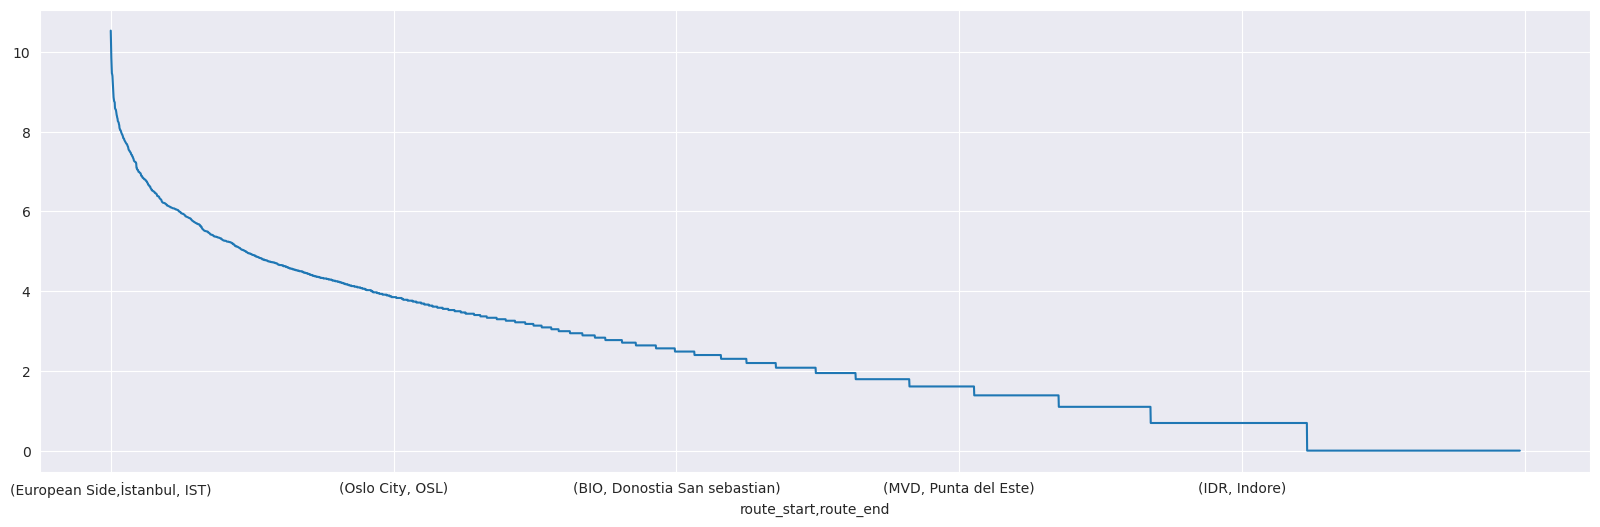

In [56]:
routes_count.plot(figsize=(20,6))
# routes_count

In [52]:
cumulative_count = routes_count.cumsum()
cumulative_count /= cumulative_count.iloc[-1]
cumulative_count = cumulative_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

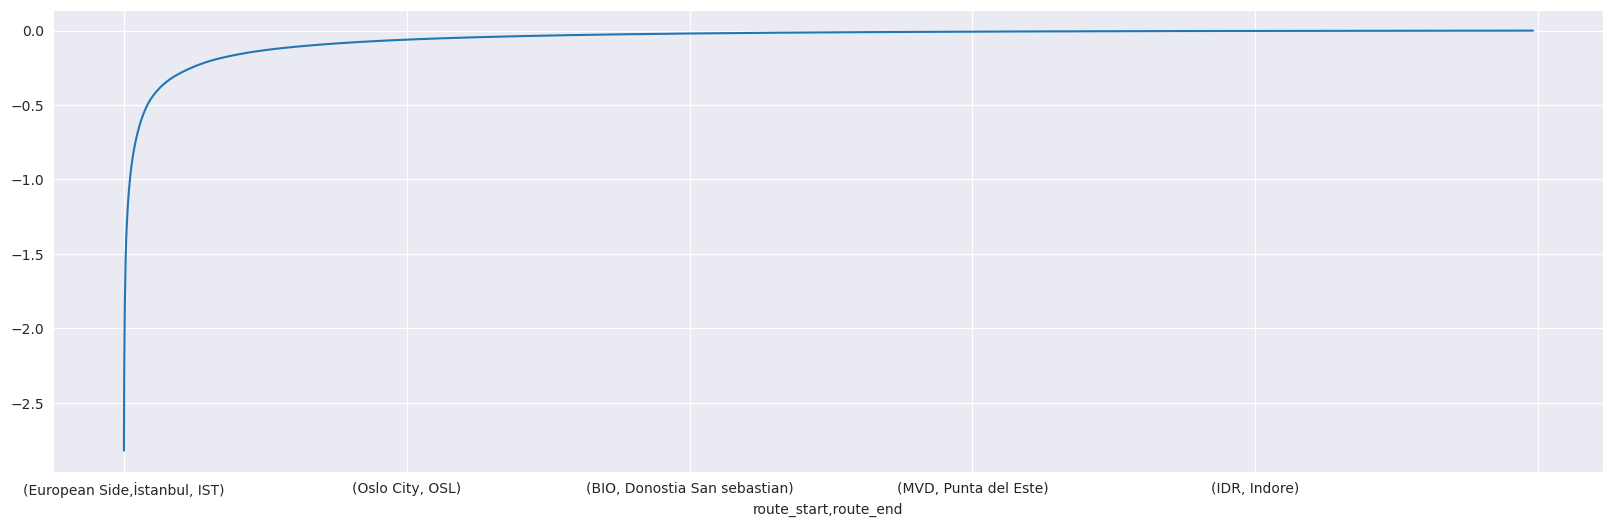

In [53]:

cumulative_count.plot(figsize=(20,6))

In [58]:
# df_routes = df.dropna(subset=['route_start', 'route_end'],how='all')
# len(df_routes)

631894

In [69]:
# # df_routes.set_index(['dispatch_id', 'route_end'], inplace=True)
# df_routes.iloc[:5,:]

,index,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,USH,Ushuaia
1,1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
2,2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
3,3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,USH,Ushuaia
4,4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,USH,Ushuaia


In [23]:
# cols = df.columns
# cols

Index(['dispatch_id', 'start_ltt_lp', 'start_lng_lp', 'end_ltt_lp',
       'end_lng_lp', 'route_start', 'route_end'],
      dtype='object')

In [24]:

# cols = [c.name for c in query.subquery().columns]
# result = [dict(zip(cols, row)) for row in df.to_numpy()]
# # result = [row for row in df.to_numpy()]
# result

[{'dispatch_id': 2979402,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.83495',
  'end_lng_lp': '-68.34771',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2615870,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2826367,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 1819243,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80264',
  'end_lng_lp': '-68.30629',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2035026,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.82094',
  'end_lng_lp': '-68.35159',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id'

In [28]:

# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum
# 
# chunk_size = 1000
# non_fpz_count = 0
# max_concurrent = 24
# 
# connection2 = sql_eng.connect()


In [25]:
# query1000= query.limit(1000)
# chunk_size=100
# raw_total_rows = 1000
# # df = pd.read_sql(query1000, sql_eng)
# # df
# for i,chunk in enumerate(tqdm(pd.read_sql(query1000,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     # for chunk in tqdm(pd.read_csv(csv_file_path, chunksize=chunk_size), total=total_lines//chunk_size +1):
#     # chunk.to_sql("price_training_labeled_2024_usd", sql_eng, if_exists='append', index=True)
#     dict_to_insert = [dict(zip(cols,row)) for row in chunk.to_numpy()]
#     insert_stmt = insert(label_archive).values(dict_to_insert)
#     session.execute(insert_stmt)
#     session.commit()



In [31]:
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
# 
#     return FPZQueryStatus.Success

# for i,chunk in enumerate(tqdm(pd.read_sql(query,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         # if i<500:
#         #     file_path = "../data/price_training_labeled_2024_usd1.csv"       
#         # else:
#         #     file_path = "../data/price_training_labeled_2024_usd2.csv"
#         file_path = "../data/price_training_labeled_2024_usd.csv"
#         with open(file_path, 'a') as f:
#             # chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#             chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#     except Exception as e:
#         print(f"\r {e}")
#         continue

Overall Progress:   0%|          | 0/1063 [00:00<?, ?it/s]

In [208]:
# df1 = df_lut.iloc[:10,:]
# df1
# len(df1)
# idx = df1.index.drop_duplicates(keep='first')
# df1[~df1.index.duplicated(keep='first')]
# df1

,,,,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,from_timezone_str,to_time_str,to_timezone_str,passenger_count,...,start_ltt,end_place_id,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end
start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,,,,,,,,,,,,,,,,,,,,,
37.61487,-122.38985,37.79414,-122.40779,123241,89521,2222284,1.0,1.740210e+09,2025-02-21 23:45,Pacific Standard Time,None,None,2.0,...,37.614871,1868.0,旧金山唐人街 美国加利福尼亚州旧金山旧金山唐人街,-122.407791,37.794138,1.0,Sedan,1,SFO,san francisco
24.07630,-110.36712,24.15539,-110.32272,186130,57630,2252856,1.0,1.709903e+09,2024-03-08 06:00,Mexican Pacific Standard Time,None,None,1.0,...,24.076300,35735.0,Malecon La Paz,-110.322718,24.155387,1.0,Sedan,1,LAP,La Paz
13.91326,100.60420,13.75957,100.54034,204703,38293,2261809,1.0,1.709262e+09,2024-03-01 10:00,Indochina Time,None,None,2.0,...,13.913260,38357.0,"酒店 104/7 Thanon Rang Nam, Khwaeng Thanon Phaya...",100.540340,13.759571,1.0,Sedan,1,DMK,市区中心
-37.82128,144.96533,-37.66901,144.84103,225395,585,2271309,1.0,NaN,"Mar 31, 2022 8:0",None,None,None,NaN,...,-37.821275,186.0,Melbourne Airport,144.841027,-37.669012,NaN,None,1,南墨尔本,MEL
40.73546,140.69041,40.29349,140.59228,282225,57783,2297841,2.0,1.725052e+09,2024-08-31 06:04,Asia/Tokyo,2024-09-01 09:50,Asia/Tokyo,3.0,...,40.735459,2029269.0,"End Location,",140.592282,40.293487,5.0,Minibus-8,1,None,None
18.76775,98.96401,18.78225,98.98766,310988,45507,2309705,2.0,1.704533e+09,2024-01-06 16:30,Indochina Time,2024-01-11 06:25,Indochina Time,2.0,...,18.767749,1681.0,Phor Liang Meun Terracotta Arts Hotel โรงแรมพ่...,98.987665,18.782251,1.0,Sedan,1,CNX,9-古城
26.08507,-80.11666,25.79375,-80.27585,315058,62025,2311454,1.0,1.705151e+09,2024-01-13 08:00,Eastern Standard Time,None,None,8.0,...,26.085070,10670.0,"Aeropuerto Miami 5600 NW 36th St, Miami, FL 33...",-80.275851,25.793748,5.0,Minibus-8,1,Fort Lauderdale,MIA
31.19348,121.35203,31.14340,121.65787,338118,36941,2321366,1.0,1.713989e+09,2024-04-25 04:00,China Standard Time,None,None,2.0,...,31.193481,22027.0,"Shanghai Disneyland Park 4MV5+945, Pudong, Sha...",121.657871,31.143397,2.0,Business Sedan,1,SHA,浦东机场圈
-34.81500,-58.53483,-34.60368,-58.38156,340666,2855,2322479,1.0,1.722413e+09,2024-07-31 05:00,Argentina Standard Time,None,None,1.0,...,-34.815004,47780.0,Buenos Aires,-58.381559,-34.603684,1.0,Sedan,1,EZE,Microcentro


10

In [28]:
# # df1 = df_lut.iloc[:10,:]
# # df1
# # len(df1)
# # idx = df1.index.drop_duplicates(keep='first')
# # df1[~df1.index.duplicated(keep='first')]
# # df1
# route_t = Table('route_lp', metadata, autoload_with=sql_eng)
# route_t = select(route_t)
# # noinspection PyUnboundLocalVariable
# connection = sql_eng.connect()


In [29]:
# s = route_t.limit(10)
# df = pd.read_sql(s,sql_eng)
# df

,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,,
1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,,
2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,,
3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,,
4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,,
5,2636003,-54.84330,-68.29580,-54.80900,-68.31558,,
6,2545121,-54.84330,-68.29580,-54.80740,-68.30604,,
7,1762309,-54.84330,-68.29580,-54.84171,-68.37298,,
8,2269213,-54.84330,-68.29580,-54.80733,-68.30539,,
9,2621659,-54.84330,-68.29580,-54.84183,-68.37259,,


In [30]:
# chunk_size = 10000

In [31]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum

In [91]:
import json

# Create a dictionary with the data
data = {"cost": None, "profit": None}
data = {"cost": '30.09', "profit": '3.09'}

# Convert the dictionary to a JSON string
json_string = json.dumps(data)

# Format the JSON string using an f-string
formatted_string = f"User Data: {json_string}"

print(json_string)

{"cost": "30.09", "profit": "3.09"}


In [32]:
# csv_lp_route_result = '../data/lp_route_result.csv'


In [ ]:
# non_fpz_count = 0
# max_concurrent = 24
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
#     
#     return FPZQueryStatus.Success
# 
# for i,chunk in enumerate(tqdm(pd.read_sql(route_t,connection,index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Progress')):
#     chunk = chunk.astype({'start_ltt_lp': float, 'start_lng_lp': float, 'end_ltt_lp': float, 'end_lng_lp': float, 'route_start': str, 'route_end': str})
#     non_fpz_count_chunk = 0
#     # get_fixed_zone_chunk(chunk)
#     # for ind,r in chunk.iterrows():
#     #     result = get_one_fpz(r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#         
#     
#     with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
#         to_do_map = {} # list[futures.Future] = [] 
#         # for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
#         for ind,r in chunk.iterrows():
#             future = executor.submit(get_one_fpz, r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#             to_do_map[future] = ind
#         done_iter = as_completed(to_do_map)
#         done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
# 
#         for future in done_iter:
#             try:
#                 status = future.result()
#             except Exception as e:
#                 # print(f"Exception: {e}")
#                 continue
# 
#             if status == FPZQueryStatus.Success:
#                 ind = to_do_map[future]
#                 try:
#                     chunk.at[ind, 'route_start'] = fpz['route_start']
#                     chunk.at[ind, 'route_end'] = fpz['route_end']
#                 except KeyError as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#                 except Exception as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#             else:
#                 non_fpz_count_chunk += 1
#                 # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
#                 continue
#         
#     non_fpz_count += non_fpz_count_chunk
#     scanned_row_number = (i+1)*chunk_size
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         with open(csv_lp_route_result, 'a') as f:
#             chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#         # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
#         # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#         print(f"\r Non_FZP count: {non_fpz_count}/{scanned_row_number}")
#     except Exception as e:
#         print(f"\r {e}, Non_FZP count: {non_fpz_count}/{scanned_row_number} ")
#         continue

Overall Progress:   0%|          | 0/107 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/10000 [00:00<?, ?it/s]

# inserted two new columns for fixed price zone start_zone and end_zone when creating sql table from csv file

In [ ]:
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN start_zone TEXT')
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN end_zone TEXT')
# start_zone_column = Column('start_zone', String)
# end_zone_column = Column('end_zone', String)
# add_column_op = AddColumn(start_zone_column, raw)


In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'


In [ ]:
# # Query the table in chunks
# query = session.query(raw)
# chunk_size =1000

In [ ]:
# batch_stmt = (
#     update(raw)  # 'raw' is your table object
#     .where(raw.c.dispatch_id == bindparam('b_dispatch_id'))
#     .values(
#         route_start=bindparam('route_start'),
#         route_end=bindparam('route_end')
#     )
# )
# print(batch_stmt)
# compiled = batch_stmt.compile()
# print(compiled.params)


In [ ]:
# result_csv = '../data/dispatch_fixed_zones_all.csv'
# for chunk in tqdm(pd.read_sql(query.statement, conn, index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Processing'):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     # print(chunk.dtypes)
#     route_list = []
#     for i,r in tqdm(chunk.iterrows(),total=chunk_size, desc='Chunk Processing', leave=False):
#         # l = [i, r['start_ltt'], r['start_lng'], r['end_ltt'], r['end_lng']]
#         # print(l)
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
# 
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             print(f"No Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 route_list.append((i, fix_price_zones['from'], fix_price_zones['to']))
#                 # fix_zone_routes_list.append(route)
#                 # chunk.at[i, 'route_start'] = fix_price_zones['from']
#                 # chunk.at[i, 'route_end'] = fix_price_zones['to']
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 # stmt = (
#                 #     update(raw)  # 'raw' is your table object
#                 #     .where(raw.c.dispatch_id == int(i))
#                 #     .values(
#                 #         route_start = fix_price_zones['from'],
#                 #         route_end = fix_price_zones['to']
#                 #     )
#                 # )
#                 # conn.execute(stmt)
#                 # conn.commit()
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#     
#     try:
#         pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv, mode='a', header=False)
#     except Exception as e:
#         print(f"csv: {e}")
#         continue
#     
#     # with sqlite_eng.begin() as conn:
#     #     conn.execute(
#     #         stmt, 
#     #         [
#     #             {
#     #                 'b_dispatch_id': i,
#     #                 'route_start': r['route_start'],
#     #                 'route_end': r['route_end']
#     #             }
#     #             for i,r in chunk.iterrows()
#     #         ],
#     #     )
#     #     conn.commit()


In [ ]:
# len(result)
# result[0]

In [ ]:

# with sql_eng.begin() as conn:
#     conn.execute(
#         batch_stmt, 
#         [
#             {
#                 'b_dispatch_id': i,
#                 'route_start': r['route_start'],
#                 'route_end': r['route_end']
#             }
#             for i,r in res.iterrows()
#         ],
#     )
#     conn.commit()


In [ ]:
# for chunk in pd.read_sql(query.statement, local_conn, chunksize=20):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     for i,r in chunk.iterrows():
#         # l = [r[0], r[1]['start_ltt'], r[1]['start_lng'], r[1]['end_ltt'], r[1]['end_lng']]
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
#         
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             j = j +1
#             print(f"{j} Not Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 # route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#                 # fix_zone_routes_list.append(route)
#                 chunk.at[i, 'route_start']
#                 
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 i = i +1
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#         
#         price_training_q = session.query(price_training_t).limit(500)
# fix_zone_routes_list = []


In [ ]:
# i = 0
# j = 0
# for pt in price_training_q:
#     # print('1')
#     # ride_samples.append(pt)
#     params = {
#         'from_lat': pt._mapping['start_ltt'],
#         'from_lng': pt._mapping['start_lng'],
#         'to_lat': pt._mapping['end_ltt'],
#         'to_lng': pt._mapping['end_lng'],
#         # 'from_utc':pt._mapping['from_utc'],
#     }
#     try:
#         response = requests.get(url=url, params=params)
#     except requests.exceptions.Timeout:
#         print('Timeout')
#         continue
#     except requests.exceptions.TooManyRedirects:
#         print('TooManyRedirects')
#         # Tell the user their URL was bad and try a different one
#     except requests.exceptions.RequestException as e:
#         print('RequestException, Catastrophic error!')
#         # continue
#         # catastrophic error. bail.
#         raise SystemExit(e)    
#         
#     except Exception as e:
#         print(f"request: {e}")
#         continue
#     # print('2')
#     try:
#         res = response.json()
#     except Exception as e:
#         print(f"json: {e}")
#         continue
#     # print('3')
#     try:
#         fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#     except KeyError as e:
#         j = j +1
#         print(f"{j} Not Fixed Price!")
#         continue
#     except IndexError as e:
#         print("IndexError for fix_price_zones")
#         continue
#     except Exception as e:
#         print(f"dict: {e}")
#         continue
#     # print('4')
#     if not isinstance(fix_price_zones,dict):
#         print(f"No fix price: {fix_price_zones}")
#     else:
#         try:
#             route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#             fix_zone_routes_list.append(route)
#             # ins = insert(fixed_zone_routes).values(
#             #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt._mapping['dispatch_id'])
#             i = i +1
#         except KeyError as e:
#             print("KeyError for route")
#             continue
# 
#         # print('5')
#         if i%50 == 0:
#             # connection.execute(ins)
#             df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
#             df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
#             fix_zone_routes_list = []
#             print(f"Created {i} records")
# 
#     # print('6')
# df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
# df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
# fix_zone_routes_list = []
# print(f"Created {i} records")
#     # print('6')
#     # print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # # print(pt._mapping['start_place'])
#     # print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # # print(pt._mapping['end_place']) 
#     # print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     # print("------------")

# Use ORM to retrieve records


In [ ]:
# sample_count = session.query(F.count(price_training_t.c.ride_id)).scalar()
# print(sample_count)
# 

In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'

In [ ]:

# params = {
#     'from_lat': 37.61911449999999,
#     'from_lng':-122.3816274,
#     'to_lat':37.3635295,
#     'to_lng':-121.9285932,
#     'from_utc':1727352000,
# }
# response = requests.get(url=url, params=params)
# response.json()


In [ ]:
# res = response.json()
# fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
# print(fix_price_zones)

In [ ]:
# ride_samples = []

In [ ]:
# pt = price_training_q.first()
# pt

In [ ]:
# params = {
#     'from_lat': (pt._mapping['start_ltt']),
#     'from_lng': (pt._mapping['start_lng']),
#     'to_lat': (pt._mapping['end_ltt']),
#     'to_lng': (pt._mapping['end_lng']),
#     # 'from_utc': int(pt._mapping['from_utc']),
# }
# params

# response = requests.get(url=url, params=params)
# res = response.json()
# res

In [ ]:
from sqlalchemy import String,Integer,insert

In [ ]:
# fix_zone_routes_list

In [ ]:
# price_training_q = session.query(price_training_t).limit(10)
# ride_samples = []
# for pt in price_training_q:
#     ride_samples.append(pt)
#     print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # print(pt._mapping['start_place'])
#     print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # print(pt._mapping['end_place']) 
#     print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     print("------------")



In [ ]:
# ride_samples[0]._mapping

In [ ]:
# df = pd.DataFrame(ride_samples)
# df

In [ ]:

# rides_q = session.query(price_training_t).limit(10)

In [ ]:

# for ride in rides_q:
#     print(ride)

In [ ]:
# rides_q = session.query(ride_ride_t).limit(10)
# for ride in rides_q:
#     print(ride)

In [ ]:
# print(price_training_t)

In [ ]:
# use core to retrieve records
# rp = connection.execute(price_training_t)
# for i, record in enumerate(rp):
#     print(i, record.ride_id)

In [ ]:
# results = rp.fetchall()
# results

In [ ]:
# df = pd.read_sql(price_training_t, engine)
# df

In [ ]:
# sqlite_eng = create_engine('sqlite:///../data/price_training_from_gbq_raw.db', echo=False)

In [ ]:
# df.to_sql('price_training_orlando_mpv5', sqlite_eng, if_exists='replace')

# Pandas Processing


## Traffic peak time exclusion
source https://www.quora.com/What-is-the-trickiest-time-of-the-day-to-drive-in-Orlando

In [ ]:
# from workalendar.usa import Florida

In [ ]:
# cal_orlando = Florida()


In [ ]:
# exclude_dates = [d[0] for d in cal_orlando.holidays(2024)]
# exclude_dates

In [ ]:
# from workalendar.usa import Florida 
# import numpy as np
# cal_florida = Florida()
# exclude_dates_str = [str(d[0]) for d in cal_florida.holidays(2024)]
# exclude_dates_str

In [ ]:
# exclude_dates = [d[0] for d in cal_florida.holidays(2024)]
# exclude_dates
# res = df['from_datetime_utc'].apply(lambda x: x in exclude_dates)

In [ ]:
# np.any(res.apply(lambda x: x in exclude_dates))
# res[0]=True
# res
# np.any(res)


In [ ]:
# from pricing.data.utils import validate_datetime_in_iso_format, validate_timezone_in_iana, get_timezone_abbreviation, fix_timezone

In [ ]:
# df_invalid_datetime = df[df.apply(lambda x: not validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_invalid_datetime

In [ ]:
# df_invalid_timezone = df[df.apply(lambda x: not validate_timezone_in_iana(x['from_timezone_str']), axis=1)]
# df_invalid_timezone

In [ ]:
#orlando_airport = pd.read_csv('../../data/orlando_all_output.csv')
#orlando_airport.head()
#orlando_airport.dtypes
#orlando_airport.to_sql('orlando_airport', sqlite_eng, if_exists='append')

In [ ]:
# df['from_timezone_fix_str'] = df.apply(lambda x: fix_timezone(x['from_timezone_str']), axis=1) 
# df

In [ ]:

# df_valid_datetime = df[df.apply(lambda x: validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_valid_timezone = df_valid_datetime[df_valid_datetime.apply(lambda x: validate_timezone_in_iana(x['from_timezone_fix_str']), axis=1)]
# df_valid_timezone


In [ ]:

# df_valid_timezone.loc[df_invalid_timezone.index, ['from_timezone_str', 'from_timezone_fix_str']]


In [ ]:
# from datetime import datetime
# import pytz
# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x['from_timezone_fix_str'])), axis=1)
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset


In [ ]:
# df_dt_str = df_valid_timezone['from_datetime_fix_str']
# df_valid_timezone['from_datetime_local'] = df_valid_timezone.apply(lambda x: (pd.to_datetime(x['from_datetime_fix_str']).to_datetime64()), axis=1)
# df_valid_timezone

In [ ]:
# df_valid_timezone.dtypes

In [ ]:

# df_valid_timezone['from_datetime_local_tz'] = df_valid_timezone.apply(lambda x: pytz.timezone(x.loc[:,'from_timezone_str']).localize(x.loc[:,'from_datetime_local']), axis=1)
# df_valid_timezone['from_timezone'] = df_valid_timezone.apply(lambda x: pytz.timezone(x['from_timezone_fix_str']), axis=1)
# df_valid_timezone


In [ ]:
# df_valid_timezone['from_datetime_tz'] = df_valid_timezone.apply(lambda x: x['from_timezone'].localize(x['from_datetime_local']), axis=1)
# df_valid_timezone
                                    # .apply(lambda x: x.localize(x.loc[:,'from_timezone_str']), axis=1))
# df_valid_timezone


# filtering out peak traffic time

In [ ]:
# peak_time_str = [('07:00:00', '09:00:00'), ('16:00:00', '19:00:00')]
# night_time_str = [('22:00:00', '6:00:00')]  # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am
# ind = []
# td = []
# for pt in peak_time_str:
#     ind.append(pd.DatetimeIndex(pt))
# ind
# for i in ind:
#     i[1]-i[0]

In [ ]:
# peak_time = []
# for pt in peak_time_str:
#     peak_time.append(pd.date_range(pt[0], pt[1], freq='h'))
# for pt in peak_time:
#     print(pt, pt.time)

In [ ]:
# peak_time_str

In [ ]:

# df_peak_traffic_time = df_valid_timezone[
#     df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1])
# ]
# df_peak_traffic_time

In [ ]:

# df_out_of_peak_traffic_time = df_valid_timezone[
#     ~ (df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1]))
# ]
# df_out_of_peak_traffic_time


In [ ]:

# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x.loc['timezone'])))
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset
# 

# filter out round trip (time reservation) with feature distance = 1 (m)

In [ ]:
# df_no_round_trip = df_valid_timezone[df_valid_timezone['distance'] > 1]

In [ ]:
# df_training = df_no_round_trip.loc[:,['ride_id', 'trip_type', 'trip_no', 'trip_count', 'ride_status', 'partner', 'fleet', 
#                 'start_place', 'end_place',
#                 'passenger_count', 'luggage_count',
#                 'dispatch_amount', 'dispatch_currency',
#                 'distance', 'duration', 'vehicle_class', 
#                 'from_datetime_tz']]
#  
# df_training['cent_price_per_km'] = df_training['dispatch_amount'] / df_training['distance']*100.0
# df_training

In [ ]:
# def average_cent_per_km(x):
#     x['average_cent_per_km'] = x['cent_price_per_km'].mean()
#     return x

In [ ]:
# def fleet_trip_no(x):
#     x['fleet_trip_count'] = len(x)
#     return x

In [ ]:
# df_fleet_statistics = df_training.loc[:, ['ride_id','fleet']]
# df_fleet_statistics

In [ ]:

# df_fleet_trip_no = df_fleet_statistics.groupby('fleet').aggregate([len])
# df_fleet_trip_no.sort_values(by=('ride_id', 'len'), ascending=False, inplace=True)
# df_fleet_trip_no


In [ ]:
# df_big_fleets = df_fleet_trip_no[df_fleet_trip_no[('ride_id','len')] >100]
# df_big_fleets

In [ ]:
# df_big_fleet_data = []
# for f in df_big_fleets.index:
#     print(f)
#     df_big_fleet_data.append(df_training[df_training['fleet'] == f])

In [ ]:
# df_big_fleet_data[0]

In [ ]:
# df_big_fleet_data[1]

In [ ]:
# df_big_fleet_data[2]

In [ ]:

# # df_training['average_cent_per_km'] = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis


In [ ]:

# df_training

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()